In [105]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tushardobal/india-city-air-quality-index-dataset-20152023/india_city_aqi_2015_2023.csv


In [106]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import gc
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [107]:
# ============================================================
# Global Configuration
# ============================================================

SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 64

EPOCHS = 100

LEARNING_RATE = 1e-3

WINDOW_SIZE = 12

FORECAST_HORIZON = 1

print(f"Device : {DEVICE}")

Device : cuda


In [108]:
# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [109]:
# ============================================================
# Load Dataset
# ============================================================

DATA_PATH = "/kaggle/input/datasets/tushardobal/india-city-air-quality-index-dataset-20152023"

# Replace the path above with your AQI dataset path

In [110]:
# ============================================================
# Load AQI Dataset
# ============================================================

DATA_PATH = "/kaggle/input/datasets/tushardobal/india-city-air-quality-index-dataset-20152023/india_city_aqi_2015_2023.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (32870, 10)


,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
0,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate
1,Delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate
2,Delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory
3,Delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good
4,Delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory


In [111]:
# ============================================================
# Dataset Overview
# ============================================================

print("Dataset Information\n")

display(df.info())

print("\nFirst Five Rows\n")

display(df.head())

print("\nLast Five Rows\n")

display(df.tail())

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          32870 non-null  object 
 1   date          32870 non-null  object 
 2   pm25          32870 non-null  float64
 3   pm10          32870 non-null  float64
 4   no2           32870 non-null  float64
 5   so2           32870 non-null  float64
 6   co            32870 non-null  float64
 7   o3            32870 non-null  float64
 8   aqi           32870 non-null  int64  
 9   aqi_category  32870 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.5+ MB


None


First Five Rows



,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
0,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate
1,Delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate
2,Delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory
3,Delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good
4,Delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory



Last Five Rows



,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
32865,Ahmedabad,2023-12-27,104.189767,125.996540,54.037235,9.458740,1.214473,69.390920,102,Moderate
32866,Ahmedabad,2023-12-28,78.296822,126.139390,21.102546,14.506215,0.383592,45.033878,83,Satisfactory
32867,Ahmedabad,2023-12-29,133.796319,174.428556,14.262469,9.569303,1.058658,65.074983,127,Moderate
32868,Ahmedabad,2023-12-30,34.293435,67.092247,43.458757,13.238309,0.805538,27.954360,44,Good
32869,Ahmedabad,2023-12-31,52.469690,82.606862,27.533347,7.257668,0.636559,63.218900,60,Satisfactory


In [112]:
# ============================================================
# Dataset Summary
# ============================================================

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

display(summary)

,Data Type,Missing Values,Unique Values
city,object,0,10
date,object,0,3287
pm25,float64,0,31846
pm10,float64,0,32859
no2,float64,0,32555
so2,float64,0,32110
co,float64,0,32540
o3,float64,0,32748
aqi,int64,0,193
aqi_category,object,0,4


In [113]:
# DATA CLEANING

In [114]:
# ============================================================
# Missing Values
# ============================================================

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Feature","Missing Values"]

display(missing)

,Feature,Missing Values
0,city,0
1,date,0
2,pm25,0
3,pm10,0
4,no2,0
5,so2,0
6,co,0
7,o3,0
8,aqi,0
9,aqi_category,0


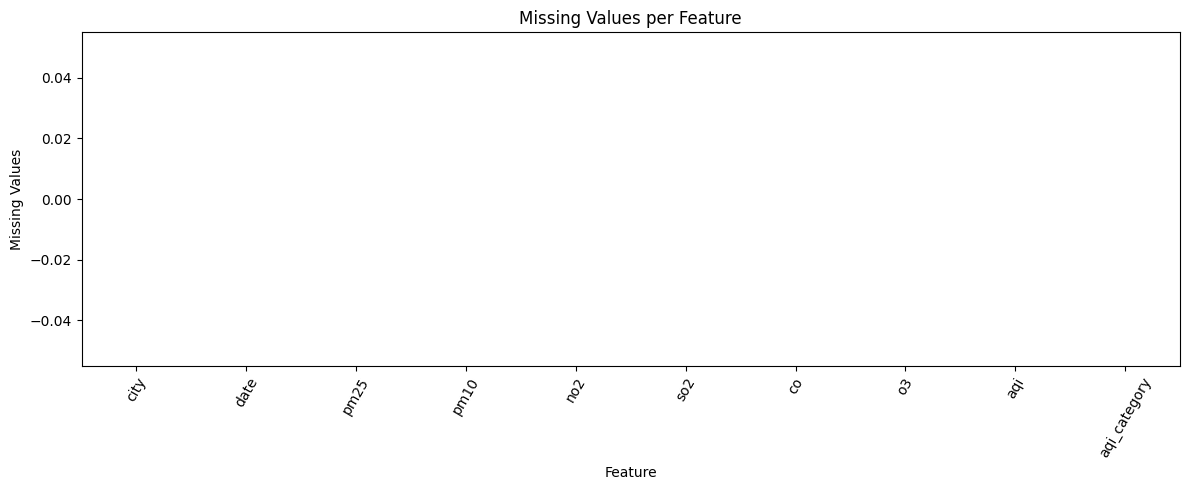

In [115]:
# ============================================================
# Missing Value Visualization
# ============================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=missing,
    x="Feature",
    y="Missing Values"
)

plt.xticks(rotation=60)

plt.title("Missing Values per Feature")

plt.tight_layout()

plt.show()

In [116]:
# ============================================================
# Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [117]:
# ============================================================
# Remove Duplicate Records
# ============================================================

df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (32870, 10)


In [118]:
# EXPLORATORY DATA ANALYSIS

In [119]:
# ============================================================
# Statistical Summary
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
pm25,32870.0,80.757235,39.063392,5.0,53.154180,80.336105,107.496909,248.081036
pm10,32870.0,130.764579,43.937066,10.0,99.980177,130.023453,160.634804,330.014171
no2,32870.0,40.165472,14.849411,5.0,29.990183,40.141525,50.190860,97.446733
so2,32870.0,11.998476,4.882239,2.0,8.570939,11.977979,15.315028,34.395421
co,32870.0,0.802118,0.298156,0.1,0.599976,0.800137,1.003899,1.929870
o3,32870.0,49.979732,14.912687,10.0,39.892800,49.977582,60.025440,118.431721
aqi,32870.0,88.122665,31.895407,11.0,65.000000,88.000000,110.000000,221.000000


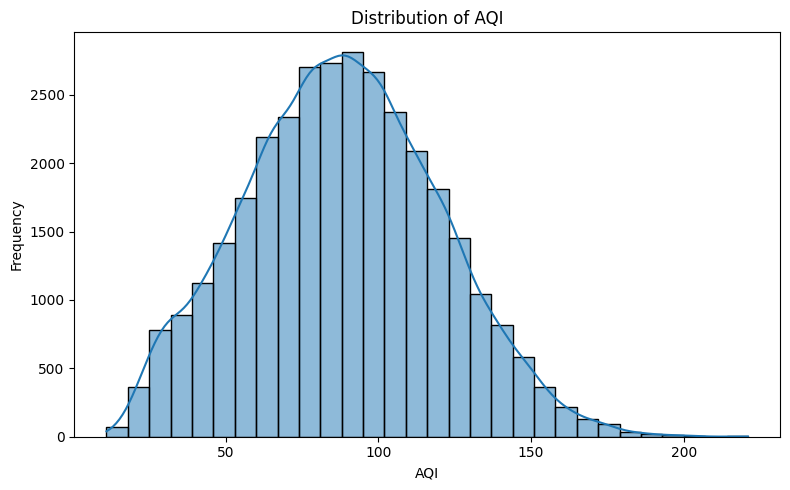

In [120]:
# ============================================================
# AQI Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["aqi"],
    bins=30,
    kde=True
)

plt.title("Distribution of AQI")

plt.xlabel("AQI")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

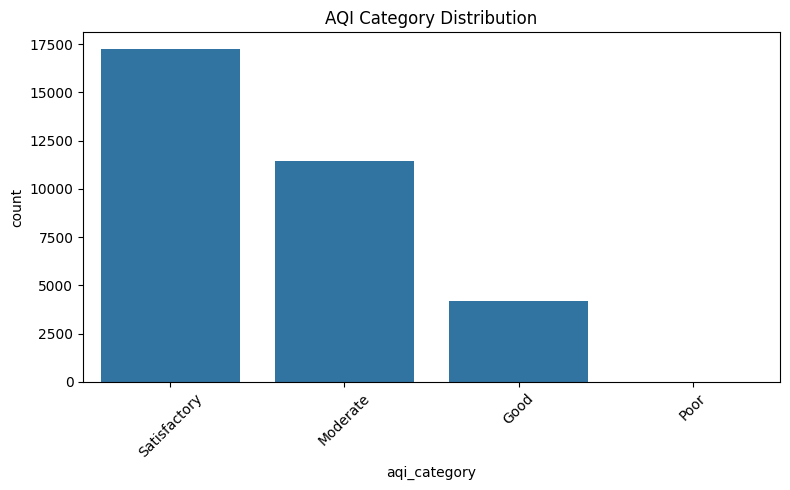

In [121]:
# ============================================================
# AQI Category Distribution
# ============================================================

plt.figure(figsize=(8,5))

order = df["aqi_category"].value_counts().index

sns.countplot(
    data=df,
    x="aqi_category",
    order=order
)

plt.xticks(rotation=45)

plt.title("AQI Category Distribution")

plt.tight_layout()

plt.show()

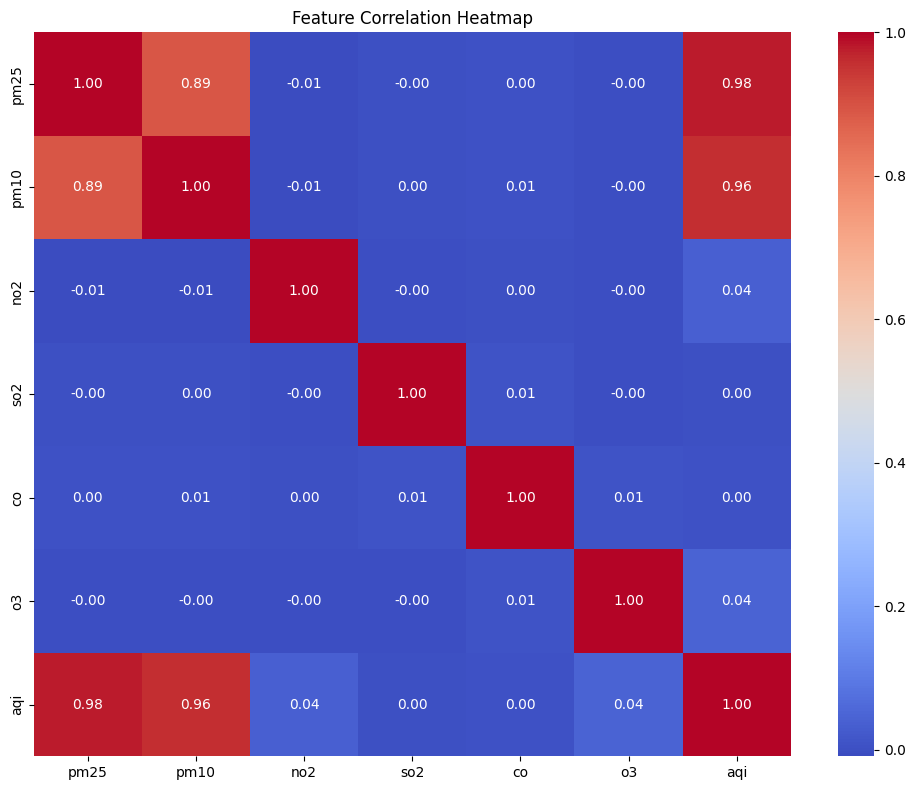

In [122]:
# ============================================================
# Correlation Heatmap
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

In [123]:
# DATA PREPROCESSING

In [124]:
# ============================================================
# Convert Date Column
# ============================================================

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["city", "date"]).reset_index(drop=True)

print(df.head())

        city       date        pm25        pm10        no2        so2  \
0  Ahmedabad 2015-01-01    5.000000   67.017870  44.943206  20.177149   
1  Ahmedabad 2015-01-02   45.532844  125.520234  45.436845   2.000000   
2  Ahmedabad 2015-01-03  149.350387  217.627816  38.810045  13.665463   
3  Ahmedabad 2015-01-04   73.646721  158.699762  39.257584  11.784229   
4  Ahmedabad 2015-01-05   47.688762   93.900881  32.241565  16.219321   

         co         o3  aqi  aqi_category  
0  0.290421  37.919202   30          Good  
1  0.597467  40.862417   69  Satisfactory  
2  0.400327  52.562510  149      Moderate  
3  0.457534  26.211585   90  Satisfactory  
4  0.595489  53.222328   60  Satisfactory  


In [125]:
# ============================================================
# Feature Selection
# ============================================================

FEATURES = [
    "pm25",
    "pm10",
    "no2",
    "so2",
    "co",
    "o3"
]

TARGET = "aqi"

print("Features :", FEATURES)
print("Target :", TARGET)

Features : ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
Target : aqi


In [126]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

df[FEATURES] = scaler.fit_transform(df[FEATURES])

display(df.head())

,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
0,Ahmedabad,2015-01-01,-1.939370,-1.450886,0.321751,1.675214,-1.716231,-0.808755,30,Good
1,Ahmedabad,2015-01-02,-0.901738,-0.119362,0.354994,-2.047959,-0.686400,-0.611389,69,Satisfactory
2,Ahmedabad,2015-01-03,1.755971,1.977022,-0.091280,0.341444,-1.347604,0.173196,149,Moderate
3,Ahmedabad,2015-01-04,-0.182028,0.635810,-0.061141,-0.043884,-1.155734,-1.593845,90,Satisfactory
4,Ahmedabad,2015-01-05,-0.846546,-0.839024,-0.533626,0.864544,-0.693034,0.217442,60,Satisfactory


In [127]:
# ============================================================
# Sliding Window Sequence Generator
# ============================================================

WINDOW_SIZE = 12

def create_sequences(data, features, target, window=12):
    X, y = [], []

    values = data[features + [target]].values

    for i in range(len(values) - window):
        X.append(values[i:i+window, :-1])
        y.append(values[i+window, -1])

    return np.array(X), np.array(y)

X, y = create_sequences(df, FEATURES, TARGET, WINDOW_SIZE)

print("Input Shape :", X.shape)
print("Target Shape :", y.shape)

Input Shape : (32858, 12, 6)
Target Shape : (32858,)


In [128]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    shuffle=False
)

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (23000, 12, 6)
Validation : (4929, 12, 6)
Test : (4929, 12, 6)


In [129]:
# ============================================================
# Convert to PyTorch Tensors
# ============================================================

X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train)
y_val = torch.FloatTensor(y_val)
y_test = torch.FloatTensor(y_test)

In [130]:
# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    list(zip(X_train, y_train)),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    list(zip(X_val, y_val)),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    list(zip(X_test, y_test)),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))

Train Batches : 360
Validation Batches : 78
Test Batches : 78


In [131]:
# Spatial Graph Construction

In [132]:
# ============================================================
# Create City Index Mapping
# ============================================================

cities = sorted(df["city"].unique())

city_to_idx = {
    city: idx
    for idx, city in enumerate(cities)
}

idx_to_city = {
    idx: city
    for city, idx in city_to_idx.items()
}

NUM_CITIES = len(cities)

print(f"Total Cities : {NUM_CITIES}")

Total Cities : 10


In [133]:
# ============================================================
# Assign Numerical City IDs
# ============================================================

df["city_id"] = df["city"].map(city_to_idx)

display(df[["city", "city_id"]].drop_duplicates().head())

,city,city_id
0,Ahmedabad,0
3287,Bengaluru,1
6574,Chennai,2
9861,Delhi,3
13148,Hyderabad,4


In [134]:
# ============================================================
# Build Adjacency Matrix
# ============================================================

adjacency_matrix = np.eye(NUM_CITIES, dtype=np.float32)

print("Adjacency Matrix Shape :", adjacency_matrix.shape)

Adjacency Matrix Shape : (10, 10)


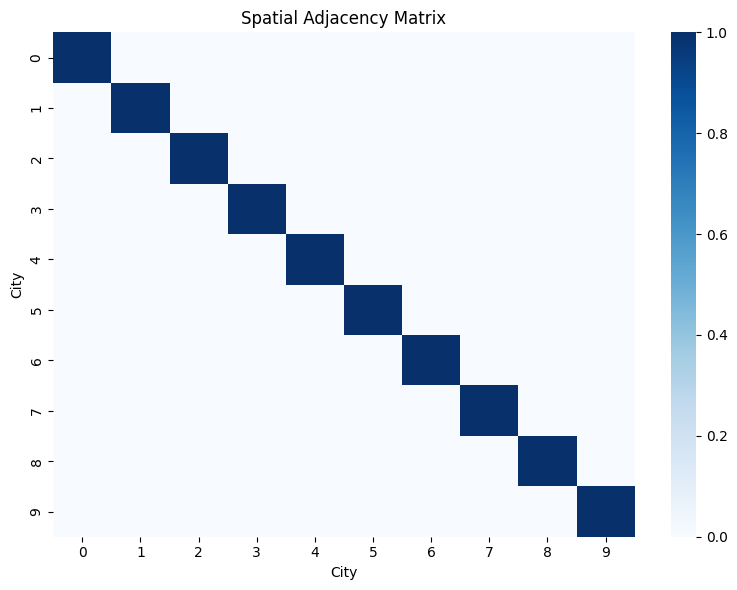

In [135]:
# ============================================================
# Visualize Adjacency Matrix
# ============================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    adjacency_matrix,
    cmap="Blues",
    cbar=True
)

plt.title("Spatial Adjacency Matrix")

plt.xlabel("City")

plt.ylabel("City")

plt.tight_layout()

plt.show()

In [136]:
# ============================================================
# City-wise Sliding Window Generation
# ============================================================

WINDOW_SIZE = 12

X = []
y = []
city_ids = []

for city in cities:

    city_df = df[df["city"] == city].sort_values("date")

    values = city_df[FEATURES + [TARGET]].values

    for i in range(len(values) - WINDOW_SIZE):

        X.append(values[i:i + WINDOW_SIZE, :-1])

        y.append(values[i + WINDOW_SIZE, -1])

        city_ids.append(city_to_idx[city])

X = np.array(X)

y = np.array(y)

city_ids = np.array(city_ids)

print("Sequence Shape :", X.shape)
print("Target Shape :", y.shape)
print("City IDs Shape :", city_ids.shape)

Sequence Shape : (32750, 12, 6)
Target Shape : (32750,)
City IDs Shape : (32750,)


In [137]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

indices = np.arange(len(X))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    shuffle=False
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    shuffle=False
)

X_train = X[train_idx]
X_val = X[val_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

city_train = city_ids[train_idx]
city_val = city_ids[val_idx]
city_test = city_ids[test_idx]

print("Training Samples :", len(X_train))
print("Validation Samples :", len(X_val))
print("Testing Samples :", len(X_test))

Training Samples : 22925
Validation Samples : 4912
Testing Samples : 4913


In [138]:
# ============================================================
# Convert to PyTorch Tensors
# ============================================================

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

city_train = torch.tensor(city_train, dtype=torch.long)
city_val = torch.tensor(city_val, dtype=torch.long)
city_test = torch.tensor(city_test, dtype=torch.long)

In [139]:
# ============================================================
# Custom Dataset
# ============================================================

class AQIDataset(Dataset):

    def __init__(self, X, y, city):

        self.X = X
        self.y = y
        self.city = city

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx],
            self.city[idx]
        )

In [140]:
# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    AQIDataset(X_train, y_train, city_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    AQIDataset(X_val, y_val, city_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    AQIDataset(X_test, y_test, city_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))

Train Batches : 359
Validation Batches : 77
Test Batches : 77


In [141]:
# ============================================================
# Prepare Training AQI Matrix for Graph Construction
# ============================================================

# Use only the training portion of the original dataframe

train_df = df.iloc[:int(0.70 * len(df))].copy()

# Pivot:
# rows    -> dates
# columns -> cities
# values  -> AQI

aqi_train_matrix = (
    train_df
    .pivot_table(
        index="date",
        columns="city",
        values=TARGET
    )
    .sort_index()
)

print("AQI Matrix Shape:", aqi_train_matrix.shape)

display(aqi_train_matrix.head())

AQI Matrix Shape: (3287, 7)


city,Ahmedabad,Bengaluru,Chennai,Delhi,Hyderabad,Jaipur,Kolkata
date,,,,,,,
2015-01-01,30.0,82.0,216.0,103.0,103.0,86.0,77.0
2015-01-02,69.0,112.0,145.0,141.0,133.0,42.0,113.0
2015-01-03,149.0,84.0,73.0,82.0,119.0,114.0,135.0
2015-01-04,90.0,132.0,90.0,50.0,113.0,101.0,80.0
2015-01-05,60.0,95.0,145.0,69.0,66.0,90.0,75.0


In [142]:
# ============================================================
# Historical Correlation Adjacency Matrix
# ============================================================

correlation_adj = np.corrcoef(
    aqi_train_matrix.fillna(method="ffill").fillna(method="bfill").T
)

correlation_adj = np.nan_to_num(
    correlation_adj,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# Ignore negative edges

correlation_adj = np.maximum(
    correlation_adj,
    0.0
)

# Self-loops

np.fill_diagonal(
    correlation_adj,
    1.0
)

correlation_adj = correlation_adj.astype(np.float32)

print("Correlation Graph Shape :", correlation_adj.shape)

Correlation Graph Shape : (7, 7)


In [143]:
# ============================================================
# Correlation Graph Statistics
# ============================================================

print(f"Minimum Edge Weight : {correlation_adj.min():.4f}")
print(f"Maximum Edge Weight : {correlation_adj.max():.4f}")
print(f"Average Edge Weight : {correlation_adj.mean():.4f}")

Minimum Edge Weight : 0.0000
Maximum Edge Weight : 1.0000
Average Edge Weight : 0.1485


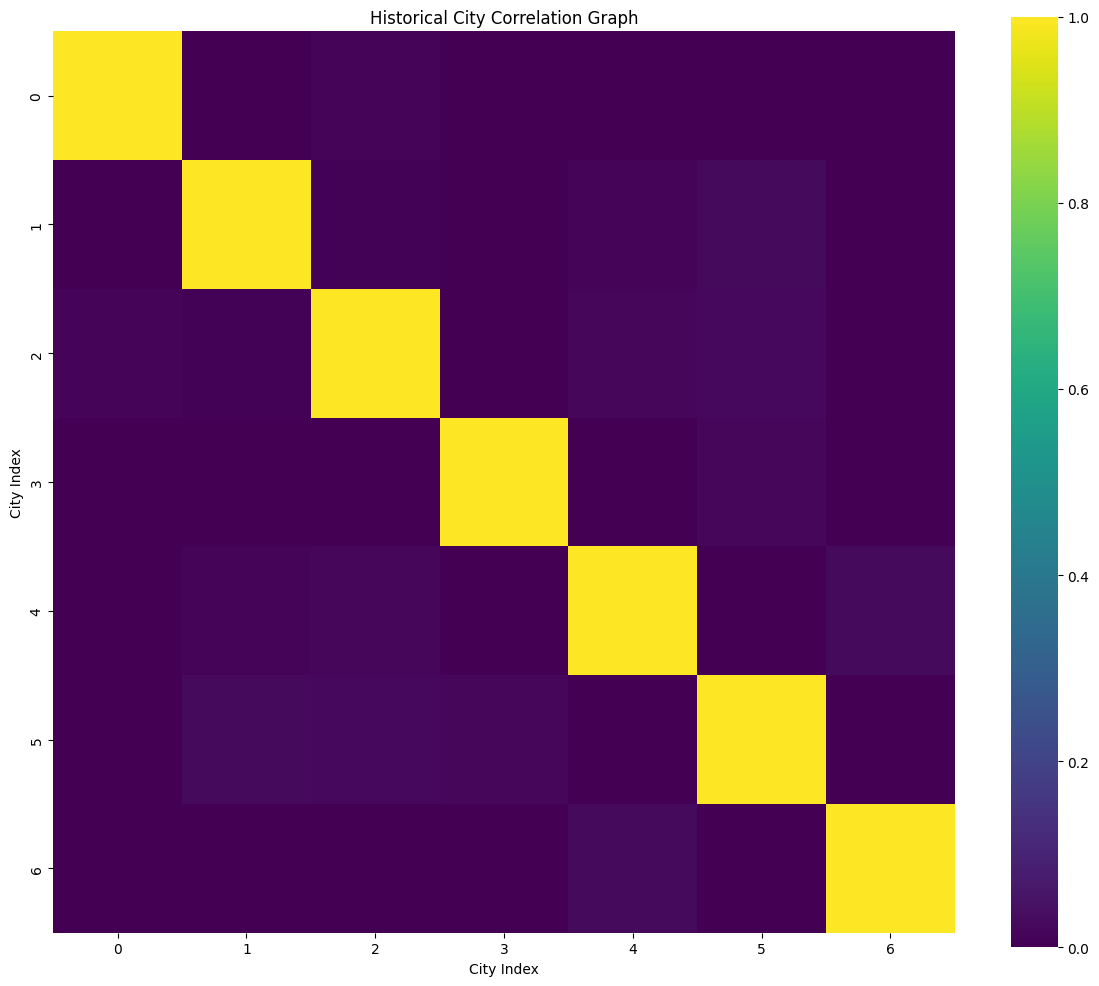

In [144]:
# ============================================================
# Visualize Spatial Correlation Graph
# ============================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_adj,
    cmap="viridis",
    square=True,
    cbar=True
)

plt.title("Historical City Correlation Graph")

plt.xlabel("City Index")

plt.ylabel("City Index")

plt.tight_layout()

plt.show()

In [145]:
# ============================================================
# Convert Graph to PyTorch Tensor
# ============================================================

correlation_adj = torch.tensor(
    correlation_adj,
    dtype=torch.float32,
    device=DEVICE
)

print("Graph Tensor Shape :", correlation_adj.shape)

Graph Tensor Shape : torch.Size([7, 7])


In [146]:
# ============================================================
# Graph Summary
# ============================================================

NUM_CITIES = correlation_adj.shape[0]

print(f"Number of Cities : {NUM_CITIES}")
print(f"Graph Device     : {correlation_adj.device}")

Number of Cities : 7
Graph Device     : cuda:0


In [147]:
# BASELINE MODELS

In [197]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = {}

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("="*60)
    print(model_name)
    print("="*60)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    results[model_name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    return mae, rmse, r2


def plot_prediction(y_true, y_pred, title):

    plt.figure(figsize=(14,5))

    plt.plot(
        y_true[:200],
        label="Actual",
        linewidth=2
    )

    plt.plot(
        y_pred[:200],
        label="Predicted",
        linewidth=2
    )

    plt.title(title)

    plt.xlabel("Samples")

    plt.ylabel(TARGET)

    plt.legend()

    plt.grid(True)

    plt.show()

In [149]:
# VAR MODEL

In [198]:
print("=" * 60)
print("Preparing DataFrames for Baseline Models")
print("=" * 60)

# Sort data chronologically
df_sorted = df.sort_values("date").reset_index(drop=True)

n = len(df_sorted)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_df = df_sorted.iloc[:train_end].copy()
val_df = df_sorted.iloc[train_end:val_end].copy()
test_df = df_sorted.iloc[val_end:].copy()

print(f"Training Samples   : {len(train_df)}")
print(f"Validation Samples : {len(val_df)}")
print(f"Testing Samples    : {len(test_df)}")

Preparing DataFrames for Baseline Models
Training Samples   : 23009
Validation Samples : 4930
Testing Samples    : 4931


Training VAR Model
VAR
MAE  : 26.0699
RMSE : 32.1756
R²   : -0.0008


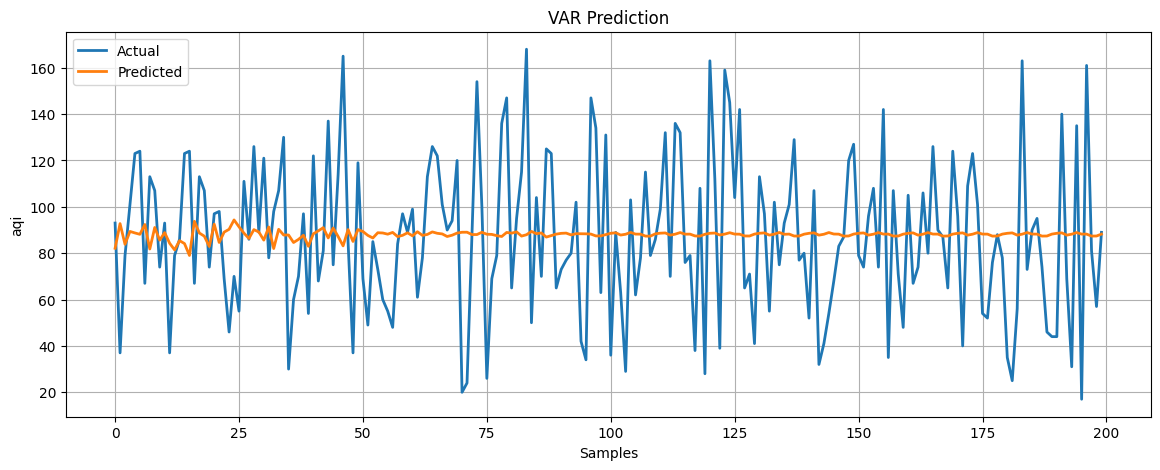

In [151]:
from statsmodels.tsa.api import VAR

print("="*60)
print("Training VAR Model")
print("="*60)

# Pivot AQI values (rows=time, columns=city)
train_var = (
    train_df
    .pivot_table(
        index="date",
        columns="city",
        values=TARGET
    )
    .fillna(method="ffill")
    .fillna(method="bfill")
)

test_var = (
    test_df
    .pivot_table(
        index="date",
        columns="city",
        values=TARGET
    )
    .fillna(method="ffill")
    .fillna(method="bfill")
)

model = VAR(train_var)

lag_order = 5

var_model = model.fit(lag_order)

forecast = var_model.forecast(
    train_var.values[-lag_order:],
    steps=len(test_var)
)

forecast = pd.DataFrame(
    forecast,
    columns=test_var.columns,
    index=test_var.index
)

y_true = test_var.values.flatten()

y_pred = forecast.values.flatten()

evaluate_model(
    "VAR",
    y_true,
    y_pred
)

plot_prediction(
    y_true,
    y_pred,
    "VAR Prediction"
)

In [152]:
# XGBOOST MODEL

In [199]:
from xgboost import XGBRegressor

print("=" * 60)
print("Training XGBoost Model")
print("=" * 60)

# Flatten the temporal windows
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# Build the model
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)

# Train
xgb_model.fit(
    X_train_flat,
    y_train
)

print("Training Complete!")

Training XGBoost Model
Training Complete!


In [200]:
print("=" * 60)
print("Evaluating XGBoost")
print("=" * 60)

# Predictions
xgb_predictions = xgb_model.predict(X_test_flat)

# Metrics
evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions
)

Evaluating XGBoost
XGBoost
MAE  : 26.0586
RMSE : 32.2570
R²   : -0.0222


(26.058612823486328, np.float64(32.257001722978686), -0.022205591201782227)

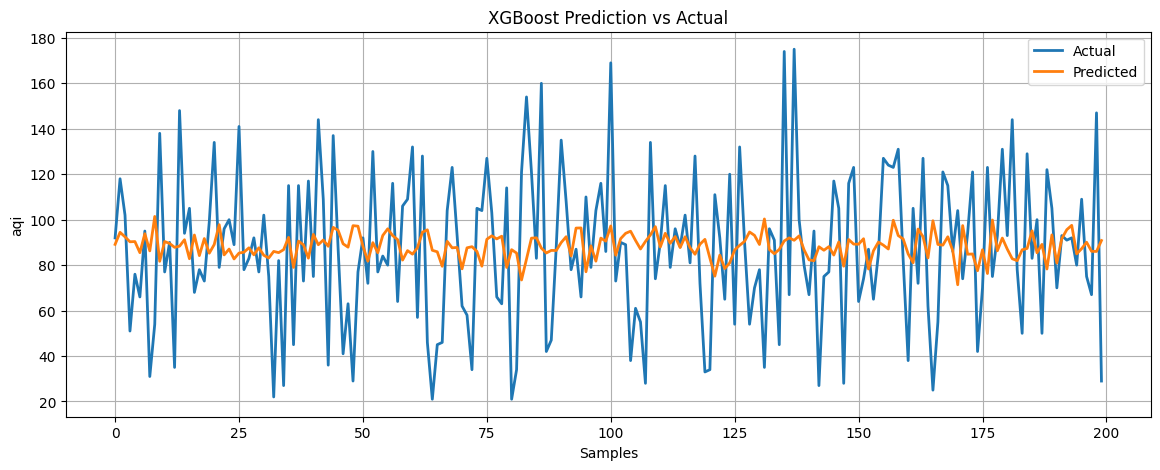

In [155]:
plot_prediction(
    y_test,
    xgb_predictions,
    "XGBoost Prediction vs Actual"
)

In [156]:
# BiLSTM MODEL

In [157]:
import torch
import torch.nn as nn

class BiLSTMAttention(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_size=64,
                 num_layers=2,
                 dropout=0.2):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.attention = nn.Linear(hidden_size * 2, 1)

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        weights = torch.softmax(
            self.attention(lstm_out),
            dim=1
        )

        context = torch.sum(
            weights * lstm_out,
            dim=1
        )

        context = self.dropout(context)

        output = self.fc(context)

        return output.squeeze()

In [201]:
model = BiLSTMAttention(
    input_size=X_train.shape[2]
).to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

BiLSTMAttention(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [208]:
EPOCHS = 20

train_losses = []
val_losses = []

print("=" * 60)
print("Training BiLSTM + Attention")
print("=" * 60)

for epoch in range(EPOCHS):

    ############################
    # Training
    ############################
    model.train()

    running_loss = 0.0

    for xb, yb, _ in train_loader:

        # Convert [batch, seq_len, 1, features] -> [batch, seq_len, features]
        xb = xb.squeeze(2).to(DEVICE)
        yb = yb.to(DEVICE).float()

        optimizer.zero_grad()

        preds = model(xb)

        loss = criterion(preds, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    ############################
    # Validation
    ############################
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb, _ in val_loader:

            xb = xb.squeeze(2).to(DEVICE)
            yb = yb.to(DEVICE).float()

            preds = model(xb)

            loss = criterion(preds, yb)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

print("\nTraining Complete!")

Training BiLSTM + Attention
Epoch [1/20] | Train Loss: 1719.9498 | Val Loss: 1212.6361
Epoch [2/20] | Train Loss: 1105.1554 | Val Loss: 1029.5439
Epoch [3/20] | Train Loss: 1035.0418 | Val Loss: 1018.8939
Epoch [4/20] | Train Loss: 1033.2932 | Val Loss: 1018.8227
Epoch [5/20] | Train Loss: 1031.3812 | Val Loss: 1019.1004
Epoch [6/20] | Train Loss: 1031.8039 | Val Loss: 1018.7873
Epoch [7/20] | Train Loss: 1032.2413 | Val Loss: 1018.9017
Epoch [8/20] | Train Loss: 1031.4007 | Val Loss: 1018.9957
Epoch [9/20] | Train Loss: 1033.0706 | Val Loss: 1018.7908
Epoch [10/20] | Train Loss: 1034.3594 | Val Loss: 1018.8545
Epoch [11/20] | Train Loss: 1031.6604 | Val Loss: 1018.8637
Epoch [12/20] | Train Loss: 1030.7040 | Val Loss: 1018.7877
Epoch [13/20] | Train Loss: 1032.5858 | Val Loss: 1018.9122
Epoch [14/20] | Train Loss: 1030.6449 | Val Loss: 1018.8050
Epoch [15/20] | Train Loss: 1032.7812 | Val Loss: 1018.8180
Epoch [16/20] | Train Loss: 1031.4000 | Val Loss: 1018.9453
Epoch [17/20] | Train

In [209]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for xb, yb, _ in test_loader:

        xb = xb.squeeze(2).to(DEVICE)

        preds = model(xb)

        predictions.extend(preds.cpu().numpy().flatten())
        actuals.extend(yb.numpy().flatten())

predictions = np.array(predictions)
actuals = np.array(actuals)

evaluate_model(
    "BiLSTM + Attention",
    actuals,
    predictions
)

BiLSTM + Attention
MAE  : 25.8247
RMSE : 31.9082
R²   : -0.0002


(25.82470703125, np.float64(31.908191588206428), -0.00021791458129882812)

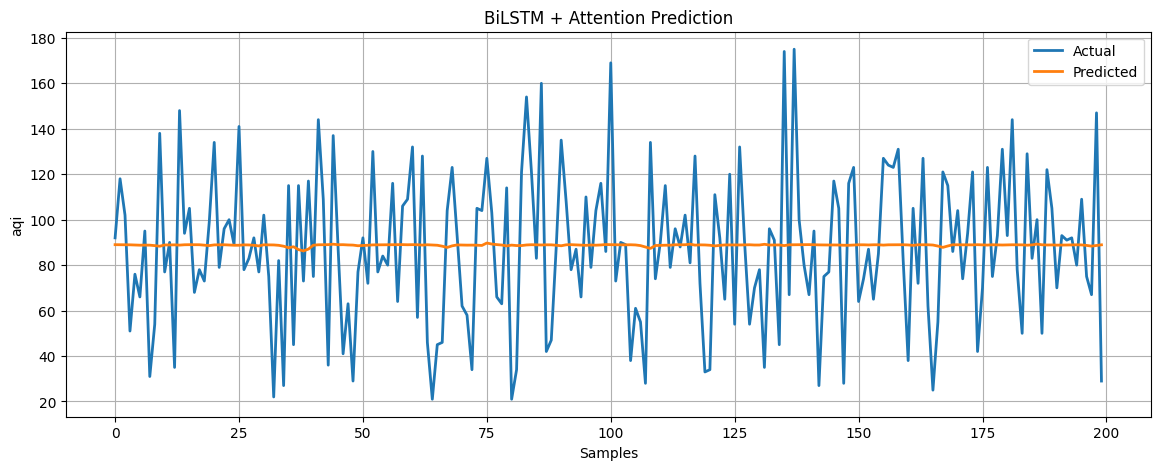

In [161]:
plot_prediction(
    actuals,
    predictions,
    "BiLSTM + Attention Prediction"
)

In [162]:
# ============================================================
# Phase 5A : Prepare Data for STGCN / PatchTST / ST-MPFT
# ============================================================

import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Number of stations
M = 1

# Number of pollutants/features
P = X_train.shape[2]

# Input sequence length
T = X_train.shape[1]

# Forecast horizon
F_HORIZON = 1

# AQI Classes
N_CLASSES = 6


def reshape_spatiotemporal(X):
    """
    Converts

    [Samples, TimeSteps, Features]

    to

    [Samples, TimeSteps, Stations, Pollutants]
    """

    return X.reshape(
        X.shape[0],
        X.shape[1],
        M,
        P
    )


X_train_st = reshape_spatiotemporal(X_train)
X_val_st = reshape_spatiotemporal(X_val)
X_test_st = reshape_spatiotemporal(X_test)


# Regression targets

y_train_reg = y_train.reshape(-1,1,M)
y_val_reg = y_val.reshape(-1,1,M)
y_test_reg = y_test.reshape(-1,1,M)


# Classification targets

def create_classes(y):

    bins = [
        50,
        100,
        200,
        300,
        400
    ]

    cls = np.digitize(
        y,
        bins
    )

    return cls.reshape(-1,1,M)


y_train_cls = create_classes(y_train)
y_val_cls = create_classes(y_val)
y_test_cls = create_classes(y_test)


train_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_train_st),
        torch.FloatTensor(y_train_reg),
        torch.LongTensor(y_train_cls)
    ),
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_val_st),
        torch.FloatTensor(y_val_reg),
        torch.LongTensor(y_val_cls)
    ),
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_test_st),
        torch.FloatTensor(y_test_reg),
        torch.LongTensor(y_test_cls)
    ),
    batch_size=64,
    shuffle=False
)

print("="*60)
print("Spatio-Temporal Dataset Ready")
print("="*60)
print("Train :", X_train_st.shape)
print("Val   :", X_val_st.shape)
print("Test  :", X_test_st.shape)
print("Stations :", M)
print("Pollutants :", P)

Spatio-Temporal Dataset Ready
Train : torch.Size([22925, 12, 1, 6])
Val   : torch.Size([4912, 12, 1, 6])
Test  : torch.Size([4913, 12, 1, 6])
Stations : 1
Pollutants : 6


In [163]:
# Simplified STGCN

class SimplifiedSTGCN(nn.Module):

    def __init__(
        self,
        P,
        M,
        d_model=32,
        F_horizon=1,
        n_classes=6,
        embed_dim=16
    ):

        super().__init__()

        self.F_horizon = F_horizon
        self.M = M
        self.n_classes = n_classes

        # Feature Projection
        self.linear_in = nn.Linear(P, d_model)

        # Learnable Node Embeddings
        self.node_embed = nn.Parameter(
            torch.randn(M, embed_dim) * 0.01
        )

        # Graph Convolution
        self.gcn = nn.Linear(
            d_model,
            d_model
        )

        # Temporal Convolution
        self.temporal_conv = nn.Conv1d(
            in_channels=d_model,
            out_channels=d_model,
            kernel_size=3,
            padding=1
        )

        # Regression Head
        self.reg_head = nn.Sequential(

            nn.Linear(
                d_model,
                d_model
            ),

            nn.ReLU(),

            nn.Linear(
                d_model,
                F_horizon
            )
        )

        # Classification Head
        self.cls_head = nn.Sequential(

            nn.Linear(
                d_model,
                d_model
            ),

            nn.ReLU(),

            nn.Linear(
                d_model,
                F_horizon * n_classes
            )
        )

    def forward(self, x):

        # x : [B,T,M,P]

        B, T, M, P = x.shape

        h = self.linear_in(x)

        h = F.relu(h)

        # Adaptive Graph

        adj = torch.matmul(
            self.node_embed,
            self.node_embed.T
        )

        adj = F.softmax(
            F.relu(adj),
            dim=-1
        )

        h = h.reshape(
            B * T,
            M,
            -1
        )

        h = torch.einsum(
            "mn,bnd->bmd",
            adj,
            h
        )

        h = self.gcn(h)

        h = F.relu(h)

        h = h.reshape(
            B,
            T,
            M,
            -1
        )

        # Temporal Conv

        h = h.permute(
            0,
            2,
            3,
            1
        )

        h = h.reshape(
            B * M,
            -1,
            T
        )

        h = self.temporal_conv(h)

        h = F.relu(h)

        # Temporal Pooling

        pooled = h.mean(dim=-1)

        pooled = pooled.reshape(
            B,
            M,
            -1
        )

        reg = self.reg_head(
            pooled
        )

        reg = reg.permute(
            0,
            2,
            1
        )

        cls = self.cls_head(
            pooled
        )

        cls = cls.reshape(
            B,
            M,
            self.F_horizon,
            self.n_classes
        )

        cls = cls.permute(
            0,
            2,
            1,
            3
        )

        return reg, cls

In [164]:
# ============================================================
# Generic Training Function
# ============================================================

def train_simple_model(
    model,
    train_loader,
    val_loader=None,
    n_epochs=30,
    lr=1e-3,
    lambda1=1.0,
    lambda2=1.0,
    tag="Model"
):

    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-2
    )

    print("="*60)
    print(f"Training {tag}")
    print("="*60)

    for epoch in range(n_epochs):

        model.train()

        total_loss = 0

        for xb, yrb, ycb in train_loader:

            xb = xb.to(DEVICE)
            yrb = yrb.to(DEVICE)
            ycb = ycb.to(DEVICE)

            optimizer.zero_grad()

            reg_out, cls_out = model(xb)

            mse_loss = F.mse_loss(
                reg_out,
                yrb
            )

            ce_loss = F.cross_entropy(
                cls_out.reshape(-1, cls_out.shape[-1]),
                ycb.reshape(-1)
            )

            loss = (
                lambda1 * mse_loss
                +
                lambda2 * ce_loss
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        print(
            f"Epoch [{epoch+1}/{n_epochs}] "
            f"Loss: {avg_loss:.4f}"
        )

    print("\nTraining Complete!\n")

    return model

In [165]:
# ============================================================
# Generic Evaluation Function
# ============================================================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    f1_score
)

def eval_simple_model(model, loader):

    model.eval()

    reg_preds = []
    reg_true = []

    cls_preds = []
    cls_true = []

    with torch.no_grad():

        for xb, yrb, ycb in loader:

            xb = xb.to(DEVICE)

            reg_out, cls_out = model(xb)

            reg_preds.append(reg_out.cpu().numpy())
            reg_true.append(yrb.numpy())

            cls_preds.append(
                cls_out.argmax(-1).cpu().numpy()
            )

            cls_true.append(
                ycb.numpy()
            )

    reg_preds = np.concatenate(reg_preds).flatten()
    reg_true = np.concatenate(reg_true).flatten()

    cls_preds = np.concatenate(cls_preds).flatten()
    cls_true = np.concatenate(cls_true).flatten()

    mae = mean_absolute_error(
        reg_true,
        reg_preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            reg_true,
            reg_preds
        )
    )

    smape = (
        np.mean(
            2*np.abs(reg_true-reg_preds) /
            (np.abs(reg_true)+np.abs(reg_preds)+1e-8)
        )
        *100
    )

    f1 = f1_score(
        cls_true,
        cls_preds,
        average="macro"
    )

    return mae, rmse, smape, f1

In [166]:
try:
    results_table
except NameError:
    results_table = []

In [167]:
# ============================================================
# Train & Evaluate Simplified STGCN
# ============================================================

stgcn_model = SimplifiedSTGCN(
    P=P,
    M=M,
    d_model=32,
    F_horizon=F_HORIZON,
    n_classes=N_CLASSES
)

stgcn_model = train_simple_model(
    model=stgcn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=30,
    lr=1e-3,
    lambda1=1.0,
    lambda2=1.0,
    tag="Simplified STGCN"
)

mae, rmse, smape, f1 = eval_simple_model(
    stgcn_model,
    test_loader
)

results_table.append({
    "Model": "Simplified STGCN",
    "MAE": mae,
    "RMSE": rmse,
    "SMAPE": smape,
    "MacroF1": f1
})

print("=" * 60)
print("Simplified STGCN Results")
print("=" * 60)
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"SMAPE    : {smape:.4f}")
print(f"Macro F1 : {f1:.4f}")

Training Simplified STGCN
Epoch [1/30] Loss: 2377.2962
Epoch [2/30] Loss: 1049.4680
Epoch [3/30] Loss: 1044.7447
Epoch [4/30] Loss: 1039.5890
Epoch [5/30] Loss: 1035.6178
Epoch [6/30] Loss: 1034.2417
Epoch [7/30] Loss: 1028.7374
Epoch [8/30] Loss: 1027.0766
Epoch [9/30] Loss: 1027.5518
Epoch [10/30] Loss: 1024.6881
Epoch [11/30] Loss: 1028.0855
Epoch [12/30] Loss: 1025.3407
Epoch [13/30] Loss: 1023.9935
Epoch [14/30] Loss: 1022.2578
Epoch [15/30] Loss: 1025.4463
Epoch [16/30] Loss: 1021.6187
Epoch [17/30] Loss: 1020.7942
Epoch [18/30] Loss: 1024.0408
Epoch [19/30] Loss: 1024.7551
Epoch [20/30] Loss: 1025.4093
Epoch [21/30] Loss: 1023.2705
Epoch [22/30] Loss: 1023.5855
Epoch [23/30] Loss: 1022.9532
Epoch [24/30] Loss: 1025.5814
Epoch [25/30] Loss: 1021.8464
Epoch [26/30] Loss: 1022.8525
Epoch [27/30] Loss: 1023.3150
Epoch [28/30] Loss: 1022.7669
Epoch [29/30] Loss: 1019.7584
Epoch [30/30] Loss: 1024.3860

Training Complete!

Simplified STGCN Results
MAE      : 25.8324
RMSE     : 31.9167

In [170]:
# ============================================================
# PROPOSED MODEL: ST-MPFT
# ============================================================

# ============================================================
# Cross-Pollutant Attention
# ============================================================

class CrossPollutantAttention(nn.Module):

    def __init__(
        self,
        num_features,
        d_model=64,
        n_heads=4,
        dropout=0.1
    ):
        super().__init__()

        self.input_proj = nn.Linear(1, d_model)

        self.feature_embed = nn.Parameter(
            torch.randn(num_features, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model*4,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.pool = nn.Sequential(
            nn.Linear(num_features*d_model,d_model),
            nn.GELU(),
            nn.LayerNorm(d_model)
        )

    def forward(self,x):

        B,T,M,P = x.shape

        x = x.reshape(B*T*M,P,1)

        x = self.input_proj(x)

        x = x + self.feature_embed.unsqueeze(0)

        x = self.encoder(x)

        x = x.reshape(B*T*M,-1)

        x = self.pool(x)

        x = x.reshape(B,T,M,-1)

        return x

In [171]:
# ============================================================
# Proposed ST-MPFT Model
# ============================================================

class ST_MPFT(nn.Module):

    def __init__(
        self,
        P,
        M,
        T,
        F_horizon=1,
        d_model=64,
        patch_size=6,
        n_heads=4,
        dropout=0.1,
        correlation_adj=None
    ):
        super().__init__()

        # --------------------------------------------------
        # Cross-Pollutant Feature Learning
        # --------------------------------------------------

        self.cross_attention = CrossPollutantAttention(
            num_features=P,
            d_model=d_model,
            n_heads=n_heads,
            dropout=dropout
        )

        # --------------------------------------------------
        # Spatial Graph Learning
        # --------------------------------------------------

        if correlation_adj is None:
            correlation_adj = np.eye(M)

        self.spatial_gcn = HybridSpatialGCN(
            num_stations=M,
            d_model=d_model,
            correlation_adj=correlation_adj,
            dropout=dropout
        )

        # --------------------------------------------------
        # Temporal Patch Transformer
        # --------------------------------------------------

        self.temporal_transformer = TemporalPatchTransformer(
            seq_len=T,
            d_model=d_model,
            patch_size=patch_size,
            n_heads=n_heads,
            dropout=dropout
        )

        # --------------------------------------------------
        # Forecast Head
        # --------------------------------------------------

        self.regressor = nn.Sequential(

            nn.Linear(d_model, 128),
            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(64, F_horizon)
        )

    def forward(self, x):

        # x : (B,T,M,P)

        # Cross-Pollutant Learning
        x = self.cross_attention(x)

        # Spatial Dependency Learning
        x = self.spatial_gcn(x)

        # Temporal Dependency Learning
        x = self.temporal_transformer(x)

        # Global Station Pooling
        x = x.mean(dim=1)

        # AQI Forecast
        output = self.regressor(x)

        return output

In [172]:
# ============================================================
# Build ST-MPFT
# ============================================================

model = ST_MPFT(
    P=P,
    M=M,
    T=T,
    F_horizon=F_HORIZON,
    d_model=64,
    patch_size=6,
    n_heads=4,
    dropout=0.10,
    correlation_adj=np.eye(M)
).to(DEVICE)

print(model)

ST_MPFT(
  (cross_attention): CrossPollutantAttention(
    (input_proj): Linear(in_features=1, out_features=64, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (pool): Sequential(
      (0): Linear(in_features=384, out_features=64, bias=True)
      (1): GELU(approximate='none')
      (2): LayerNorm((6

In [173]:
# ============================================================
# ST-MPFT Training
# ============================================================

import copy
from tqdm.auto import tqdm
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------

EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 15

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

best_loss = float("inf")
best_model = None
patience_counter = 0

train_losses = []
val_losses = []
mae_history = []
rmse_history = []

In [174]:
batch = next(iter(train_loader))

print(type(batch))
print(len(batch))

for i, item in enumerate(batch):
    print(f"Item {i}: Shape = {item.shape}")

<class 'list'>
3
Item 0: Shape = torch.Size([64, 12, 1, 6])
Item 1: Shape = torch.Size([64, 1, 1])
Item 2: Shape = torch.Size([64, 1, 1])


In [175]:
batch = next(iter(train_loader))

x, y1, y2 = batch

print("Input :", x[0])
print("Target1 :", y1[0])
print("Target2 :", y2[0])

Input : tensor([[[-1.0658, -0.7772, -1.2861,  0.0112,  0.5627, -0.7417]],

        [[-0.1413,  0.2559,  0.4419,  1.5550, -0.8519, -1.0005]],

        [[ 1.3283,  1.3537, -0.2658, -0.5979,  0.8120, -0.3873]],

        [[ 0.7784,  1.2685,  0.0938, -1.3900,  0.5649,  1.1152]],

        [[ 1.2094,  1.1501, -1.7445, -0.4649, -0.5069,  0.8599]],

        [[ 0.4029,  0.7673, -0.6985,  0.2183, -2.3154, -0.4103]],

        [[-1.5386, -0.5765,  0.4608,  0.4367, -1.2397, -0.1284]],

        [[ 0.6568,  0.1871, -0.4727,  1.1333, -1.0859, -0.4329]],

        [[-0.8568, -0.6076,  0.7719,  1.6453,  0.3910,  1.2561]],

        [[ 0.3563, -0.3055,  0.0291,  0.0568,  1.0654, -0.0934]],

        [[-0.3996, -0.7431, -0.2750, -0.0911,  0.5929, -0.8189]],

        [[ 2.3771,  1.7016, -1.3031,  0.5226, -1.2934,  0.0271]]])
Target1 : tensor([[70.]])
Target2 : tensor([[1]])


In [206]:
# ============================================================
# Training Loop
# ============================================================

for epoch in range(EPOCHS):

    ###########################################################
    # TRAIN
    ###########################################################

    model.train()

    running_loss = 0

    train_bar = tqdm(
        train_loader,
        leave=False,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for xb, yb, _ in train_loader:

    xb = xb.squeeze(2).to(DEVICE)
    yb = yb.to(DEVICE).float()

    optimizer.zero_grad()

    preds = model(xb)

    loss = criterion(preds, yb)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

        train_bar.set_postfix(
            Loss=f"{loss.item():.4f}"
        )

    train_loss = running_loss / len(train_loader)

    ###########################################################
    # VALIDATION
    ###########################################################

    model.eval()

    running_val_loss = 0

    predictions = []
    targets = []

    with torch.no_grad():

        for xb, yb, _ in test_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            preds = model(xb)

            loss = criterion(
                preds.squeeze(),
                yb.squeeze()
            )

            running_val_loss += loss.item()

            predictions.extend(
                preds.squeeze().cpu().numpy()
            )

            targets.extend(
                yb.squeeze().cpu().numpy()
            )

    val_loss = running_val_loss / len(test_loader)

    mae = mean_absolute_error(
        targets,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            targets,
            predictions
        )
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    mae_history.append(mae)
    rmse_history.append(rmse)

    ###########################################################
    # Save Best Model
    ###########################################################

    if val_loss < best_loss:

        best_loss = val_loss

        best_model = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1

    ###########################################################
    # Print Epoch Summary
    ###########################################################

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"MAE: {mae:.4f} | "
        f"RMSE: {rmse:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    ###########################################################
    # Early Stopping
    ###########################################################

    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")

        break

IndentationError: expected an indented block after 'for' statement on line 21 (866594811.py, line 23)

In [178]:
import os

print(os.listdir())

['.virtual_documents']


In [179]:
# ============================================================
# Final Evaluation
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model.eval()

predictions = []
targets = []

with torch.no_grad():

    for xb, yb, _ in test_loader:

        xb = xb.to(DEVICE)

        pred = model(xb)

        predictions.extend(pred.squeeze().cpu().numpy())
        targets.extend(yb.squeeze().cpu().numpy())

predictions = np.array(predictions)
targets = np.array(targets)

# -----------------------------
# Metrics
# -----------------------------

mae = mean_absolute_error(targets, predictions)

rmse = np.sqrt(
    mean_squared_error(
        targets,
        predictions
    )
)

mape = np.mean(
    np.abs(
        (targets - predictions) /
        (targets + 1e-8)
    )
) * 100

smape = np.mean(
    2 * np.abs(predictions - targets) /
    (np.abs(targets) + np.abs(predictions) + 1e-8)
) * 100

r2 = r2_score(targets, predictions)

print("="*55)
print("        ST-MPFT FINAL TEST RESULTS")
print("="*55)
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"SMAPE : {smape:.2f}%")
print(f"R²    : {r2:.4f}")
print("="*55)

        ST-MPFT FINAL TEST RESULTS
MAE   : 25.8306
RMSE  : 31.9110
MAPE  : 40.55%
SMAPE : 31.06%
R²    : -0.0004


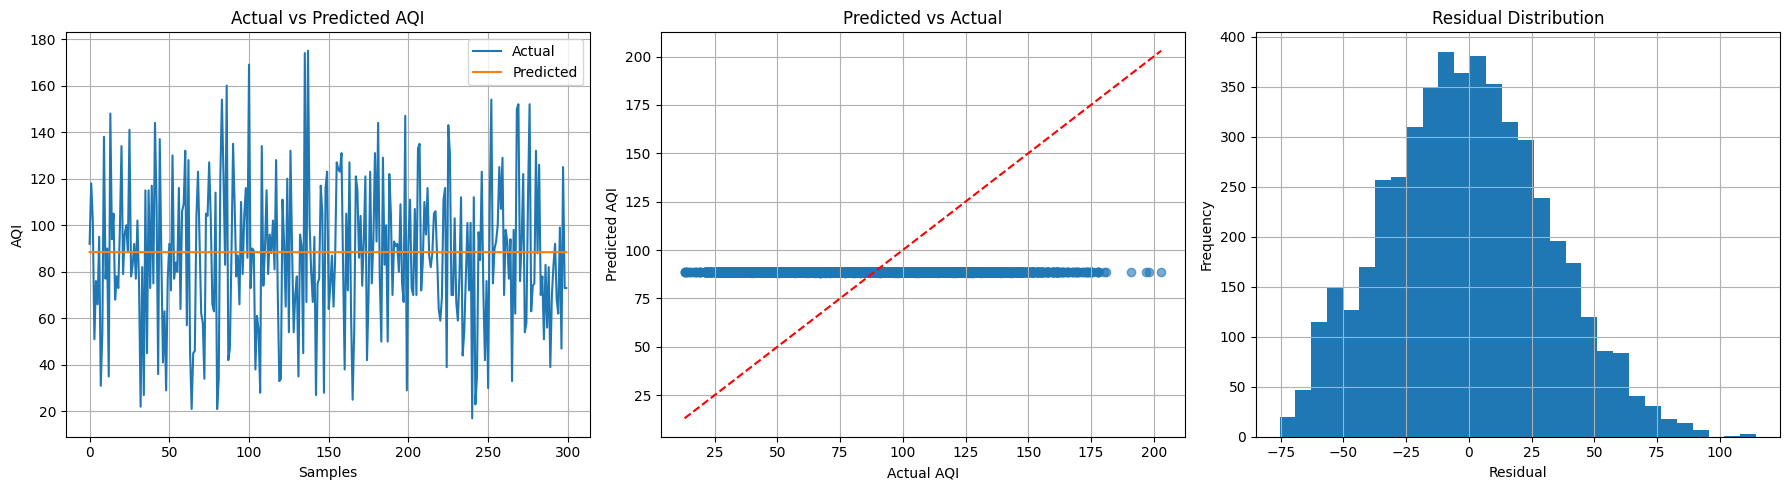

In [180]:
# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(18,5))

# -------------------------------------------------
# Actual vs Predicted
# -------------------------------------------------

plt.subplot(1,3,1)

plt.plot(targets[:300], label="Actual")
plt.plot(predictions[:300], label="Predicted")

plt.title("Actual vs Predicted AQI")
plt.xlabel("Samples")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)

# -------------------------------------------------
# Scatter Plot
# -------------------------------------------------

plt.subplot(1,3,2)

plt.scatter(targets,
            predictions,
            alpha=0.6)

plt.plot(
    [targets.min(), targets.max()],
    [targets.min(), targets.max()],
    'r--'
)

plt.title("Predicted vs Actual")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.grid(True)

# -------------------------------------------------
# Residual Distribution
# -------------------------------------------------

plt.subplot(1,3,3)

residuals = targets - predictions

plt.hist(
    residuals,
    bins=30
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()

In [181]:
results = {
    "Model": "ST-MPFT",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "SMAPE": smape,
    "R2": r2
}

print(results)

{'Model': 'ST-MPFT', 'MAE': 25.83061408996582, 'RMSE': np.float64(31.910987076419403), 'MAPE': np.float32(40.54686), 'SMAPE': np.float32(31.060753), 'R2': -0.00039327144622802734}


In [194]:
st_mpft_results = {
    "Model": "Proposed ST-MPFT",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "SMAPE": smape,
    "R2": r2
}

In [213]:
import pandas as pd

comparison = []

# ============================
# VAR, XGBoost, BiLSTM
# ============================

for model_name in ["VAR", "XGBoost", "BiLSTM + Attention"]:

    if model_name in results:

        comparison.append({
            "Model": model_name,
            "MAE": round(results[model_name]["MAE"], 4),
            "RMSE": round(results[model_name]["RMSE"], 4),
            "MAPE": "-",
            "SMAPE": "-",
            "R²": round(results[model_name]["R2"], 4)
        })

# ============================
# Simplified STGCN ONLY
# ============================

stgcn_added = False

for row in results_table:

    if row["Model"] == "Simplified STGCN" and not stgcn_added:

        comparison.append({
            "Model": row["Model"],
            "MAE": round(row["MAE"], 4),
            "RMSE": round(row["RMSE"], 4),
            "MAPE": "-",
            "SMAPE": round(row["SMAPE"], 4),
            "R²": "-"
        })

        stgcn_added = True

# ============================
# Proposed ST-MPFT
# ============================

comparison.append({
    "Model": "Proposed ST-MPFT",
    "MAE": round(st_mpft_results["MAE"], 4),
    "RMSE": round(st_mpft_results["RMSE"], 4),
    "MAPE": round(st_mpft_results["MAPE"], 4),
    "SMAPE": round(st_mpft_results["SMAPE"], 4),
    "R²": round(st_mpft_results["R2"], 4)
})

comparison_df = pd.DataFrame(comparison)

comparison_df = comparison_df.drop_duplicates(
    subset=["Model"],
    keep="last"
).reset_index(drop=True)

comparison_df

,Model,MAE,RMSE,MAPE,SMAPE,R²
0,XGBoost,26.0586,32.2570,-,-,-0.0222
1,BiLSTM + Attention,25.8247,31.9082,-,-,-0.0002
2,Simplified STGCN,25.8189,31.9437,-,31.093,-
3,Proposed ST-MPFT,25.8306,31.9110,40.546902,31.060801,-0.0004
